In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
# 忽略所有警告 (建議在開發完成、確認邏輯正確後再使用)
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

# 解決中文顯示問題 (針對 Windows 系統)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # 設定字體為微軟正黑體
plt.rcParams['axes.unicode_minus'] = False              # 解決負號 '-' 顯示為亂碼的問題

In [2]:
import pandas as pd
import os

# 設定路徑
path = 'data/'

# 1. 讀取並直接設定
#  index
data1 = pd.read_csv(os.path.join(path, 'market_indices.csv'), encoding='utf-8-sig')
data1['日期'] = pd.to_datetime(data1['日期'])
data1.set_index('日期', inplace=True)

data2 = pd.read_csv(os.path.join(path, 'vix_index.csv'), encoding='utf-8-sig')
data2['日期'] = pd.to_datetime(data2['日期'])
data2.set_index('日期', inplace=True)

data3 = pd.read_csv(os.path.join(path, 'futures_chip.csv'), encoding='utf-8-sig')
data3['日期'] = pd.to_datetime(data3['日期'])
data3.set_index('日期', inplace=True)

data4 = pd.read_csv(os.path.join(path, 'margin_and_legal.csv'), encoding='utf-8-sig')
data4['日期'] = pd.to_datetime(data4['日期'])
data4.set_index('日期', inplace=True)

print("🎯 所有資料表的 Index 已轉換為『日期』。")
# 檢查其中一個表的結果


🎯 所有資料表的 Index 已轉換為『日期』。


In [79]:
vix = data2[["VIX_收盤價"]]
twa00 = data1["加權報酬指數:收盤價"]

tw_returns = data1["加權報酬指數:收盤價"].pct_change().dropna()
vix["大盤"] = tw_returns
vix["vix_change"] = vix["VIX_收盤價"].pct_change().dropna() 
vix.dropna(inplace=True)
vix.loc[(vix["大盤"]>0.015)&(vix["vix_change"]>0), "signal"] = 1 
vix.fillna(0, inplace=True)
vix_strange_up = vix[vix["signal"] ==   1]
vix_strange_up


,VIX_收盤價,大盤,vix_change,signal
日期,,,,
2010-04-26,20.00,0.019145,0.017812,1.0
2010-09-13,16.59,0.025596,0.034289,1.0
2011-04-06,16.34,0.016869,0.001225,1.0
2012-02-08,20.52,0.021080,0.017857,1.0
2012-07-31,18.52,0.015998,0.020386,1.0
2015-04-23,13.08,0.019192,0.138381,1.0
2015-08-31,27.53,0.019685,0.033796,1.0
2015-11-04,16.16,0.016510,0.116793,1.0
2017-06-26,12.17,0.019297,0.170192,1.0


In [4]:
vix

,VIX_收盤價,大盤,vix_change,signal
日期,,,,
2010-01-15,17.53,0.008072,-0.010722,0.0
2010-01-18,19.71,-0.002282,0.124358,0.0
2010-01-19,18.87,-0.010653,-0.042618,0.0
2010-01-20,19.17,-0.003403,0.015898,0.0
2010-01-21,15.47,-0.011320,-0.193010,0.0
...,...,...,...,...
2026-04-01,34.85,0.045804,-0.058108,0.0
2026-04-02,36.45,-0.018156,0.045911,0.0
2026-04-07,33.62,0.020182,-0.077641,0.0


In [5]:
#外資累計買賣超
fi = data4["外資買賣超"].cumsum()

In [6]:
#分產業外資累計買賣超
fi_3ind  = pd.DataFrame({
    "傳產外資買賣超": data4["不含金電外資買賣超"].cumsum(),
    "金融外資買賣超": data4["金融外資買賣超"].cumsum(),     
    "電子外資買賣超": data4["電子外資買賣超"].cumsum()
})


In [7]:
fi_3ind

,傳產外資買賣超,金融外資買賣超,電子外資買賣超
日期,,,
2004-01-02,NaN,521663,4999365
2004-01-05,NaN,487756,8416771
2004-01-06,NaN,1015809,12911360
2004-01-07,NaN,1666717,16736053
2004-01-08,NaN,3265102,19567647
...,...,...,...
2026-04-01,28858534.0,192194061,-1156612026
2026-04-02,27320054.0,193408673,-1189307966
2026-04-07,28638788.0,193564741,-1184101092


<Axes: xlabel='日期'>

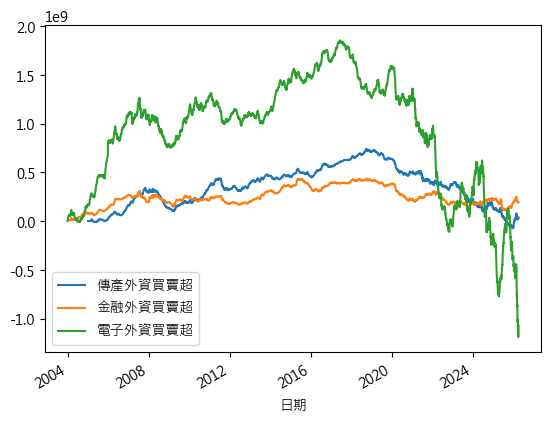

In [8]:
fi_3ind.plot()

In [9]:

#投信累計買賣超
i1= data4["投信買賣超"].cumsum()


#自營商累計買賣超
i2= data4["自營商買賣超"].cumsum()


In [10]:
#上市櫃乖離差

In [11]:
def calculate_deviation(data, window=60):
    return (data - data.rolling(window=window).mean()) / data.rolling(window=window).mean() * 100
otc_deviation = calculate_deviation(data1["OTC指數:收盤價"])
market_deviation = calculate_deviation(data1["加權指數:收盤價"])

mo_deviation = market_deviation-otc_deviation


<Axes: xlabel='日期'>

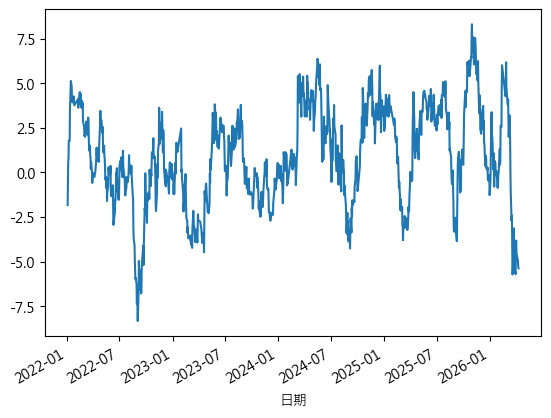

In [12]:
mo_deviation.loc['2022':].plot()



In [13]:
#電金乖離差、電傳乖離差
tech_deviation = calculate_deviation(data1["電子類:收盤價"])
fin_devation = calculate_deviation(data1["金融保險:收盤價"])
tra_deviation = calculate_deviation(data1["不含金融電子:收盤價"])

#電金乖離差
tech_fin_deviation = tech_deviation - fin_devation
#電傳乖離差
tech_tra_deviation = tech_deviation - tra_deviation


In [ ]:
# 散戶淨部位

law = data3["MTX01自營商:多方未平倉"] + data3["MTX02投信:多方未平倉"] +data3["MTX03外資:多方未平倉"]  
mob = (-law).rolling(window=5).mean()

In [15]:
#外資淨部位
foreign_net =  data3["TX03外資:期貨多方未平倉"] - data3["TX03外資:期貨空方未平倉"]

In [48]:
ll = data3["MTX01自營商:多方未平倉"] + data3["MTX02投信:多方未平倉"] +data3["MTX03外資:多方未平倉"]
ls = data3["MTX01自營商:空方未平倉"] +data3["MTX02投信:空方未平倉"]  + data3["MTX03外資:空方未平倉"]   

In [53]:
data3["MTX近期:未沖銷契約數"]

日期
2004-01-02     5981
2004-01-05     6468
2004-01-06     6667
2004-01-07     6618
2004-01-08     6703
              ...  
2026-04-01    33144
2026-04-02    27933
2026-04-07    26474
2026-04-08    29031
2026-04-09    27948
Name: MTX近期:未沖銷契約數, Length: 5476, dtype: int64

In [56]:
ll = (
    data3["MTX01自營商:多方未平倉"]
    + data3["MTX02投信:多方未平倉"]
    + data3["MTX03外資:多方未平倉"]
)

ls = (
    data3["MTX01自營商:空方未平倉"]
    + data3["MTX02投信:空方未平倉"]
    + data3["MTX03外資:空方未平倉"]
)

retail_ratio = -1 * (ll - ls) / data3["MTX近期:未沖銷契約數"]

In [75]:
twa00["多空比"] = retail_ratio

In [78]:
twa00

日期
2010-01-14 00:00:00                                              10633.6
2010-01-15 00:00:00                                             10719.43
2010-01-18 00:00:00                                             10694.97
2010-01-19 00:00:00                                             10581.04
2010-01-20 00:00:00                                             10545.03
                                             ...                        
2026-04-02 00:00:00                                             74300.61
2026-04-07 00:00:00                                             75800.17
2026-04-08 00:00:00                                             79293.86
2026-04-09 00:00:00                                             79523.06
多空比                    日期
2004-01-02         NaN
2004-01-05         N...
Name: 加權報酬指數:收盤價, Length: 3977, dtype: object

In [81]:
twa00 = pd.DataFrame(twa00)

In [84]:
twa00["多空比"] = retail_ratio

In [86]:
twa00["報酬率"] = twa00["加權報酬指數:收盤價"].pct_change()


In [ ]:
df = twa00.copy()

df["ratio_lag"] = df["多空比"].shift(1)
df["ratio_change"] = df["多空比"] - df["ratio_lag"]

df["up"] = df["報酬率"] > 0
df["down"] = df["報酬率"] < 0

# signals
df["long_signal"] = (
    (df["多空比"] < 0) &
    (df["up"]) &
    (df["ratio_change"] < 0)
)

df["short_signal"] = (
    (df["多空比"] > 0.2) &
    (df["down"]) &
    (df["ratio_change"] > 0)
)

# position
df["position"] = 0
df.loc[df["long_signal"], "position"] = 1
df.loc[df["short_signal"], "position"] = -1

# strategy return
df["strategy_return"] = df["position"].shift(1) * df["報酬率"]

# cumulative return
df["cum_return"] = (1 + df["strategy_return"]).cumprod()

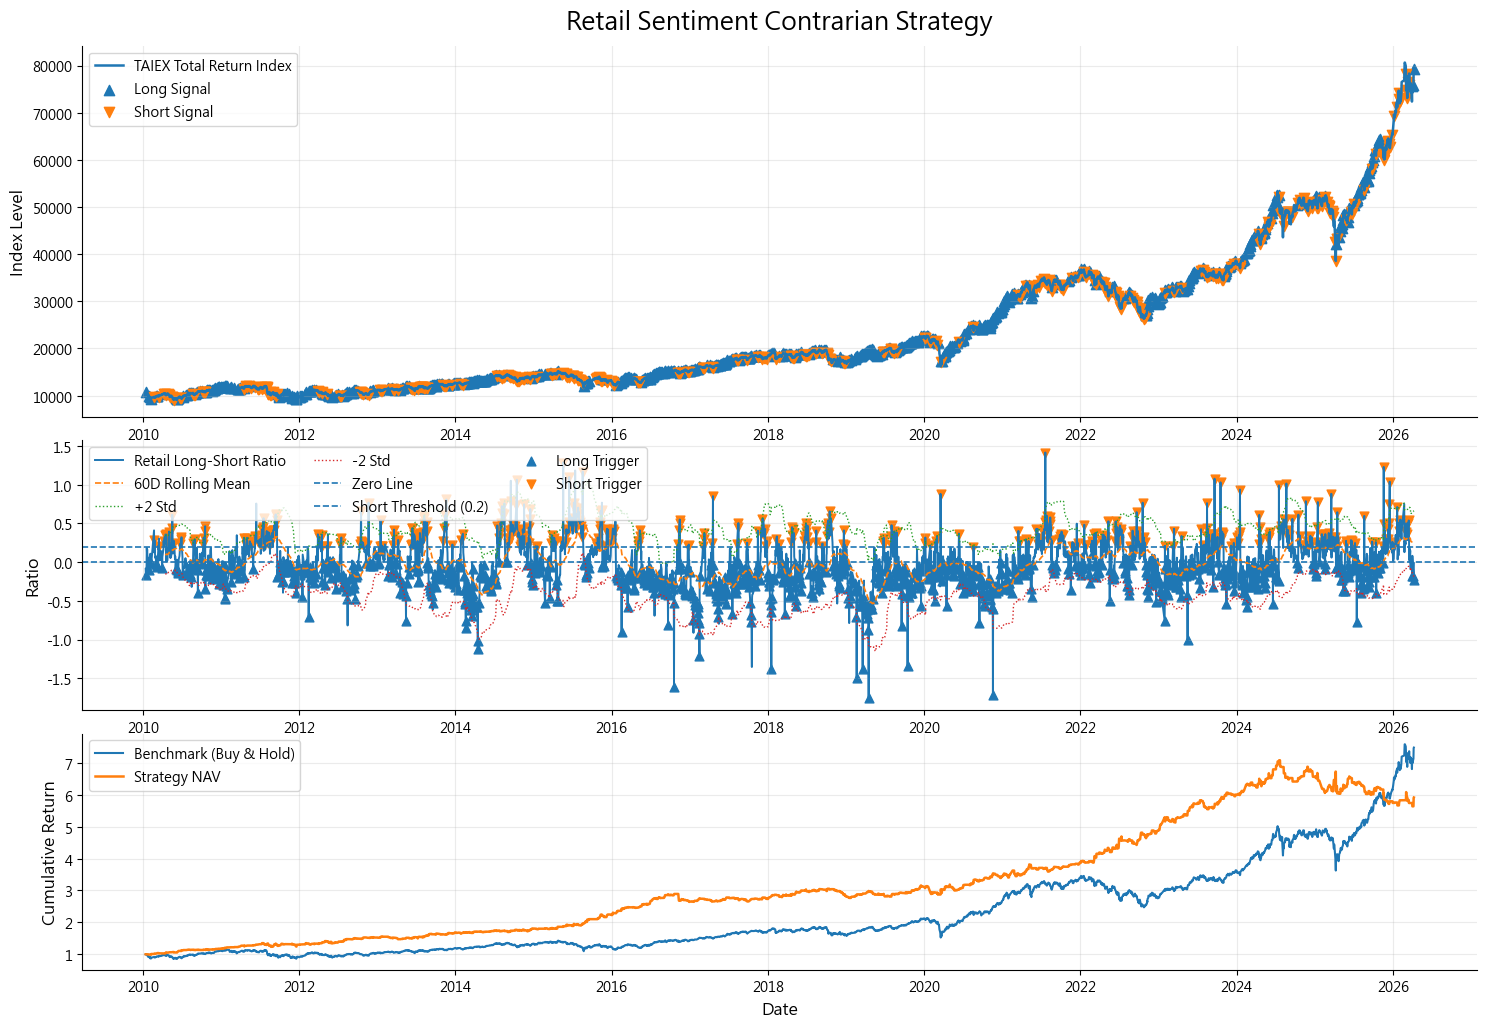

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= 1. 複製資料 =========
df = twa00.loc[:].copy()
df = df.sort_index()

# ========= 2. 建立策略邏輯 =========
df["ratio_lag"] = df["多空比"].shift(1)
df["ratio_change"] = df["多空比"] - df["ratio_lag"]

df["long_signal"] = (
    (df["多空比"] < 0) &
    (df["報酬率"] > 0) &
    (df["ratio_change"] < 0)
)

df["short_signal"] = (
    (df["多空比"] > 0.2) &
    (df["報酬率"] < 0) &
    (df["ratio_change"] > 0)
)

df["position"] = 0
df.loc[df["long_signal"], "position"] = 1
df.loc[df["short_signal"], "position"] = -1

# 隔天進場
df["strategy_return"] = df["position"].shift(1) * df["報酬率"]
df["cum_strategy"] = (1 + df["strategy_return"].fillna(0)).cumprod()
df["cum_index"] = (1 + df["報酬率"].fillna(0)).cumprod()

# ========= 3. 滾動統計，讓圖更專業 =========
lookback = 60
df["ratio_ma"] = df["多空比"].rolling(lookback).mean()
df["ratio_std"] = df["多空比"].rolling(lookback).std()
df["ratio_upper"] = df["ratio_ma"] + 2 * df["ratio_std"]
df["ratio_lower"] = df["ratio_ma"] - 2 * df["ratio_std"]

# ========= 4. 畫圖 =========
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[2.2, 1.6, 1.4], hspace=0.08)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)

# -------------------------------
# Panel 1: 指數 + 進出場點
# -------------------------------
ax1.plot(df.index, df["加權報酬指數:收盤價"], linewidth=1.8, label="TAIEX Total Return Index")

# 做多訊號
ax1.scatter(
    df.index[df["long_signal"]],
    df.loc[df["long_signal"], "加權報酬指數:收盤價"],
    marker="^",
    s=55,
    label="Long Signal"
)

# 做空訊號
ax1.scatter(
    df.index[df["short_signal"]],
    df.loc[df["short_signal"], "加權報酬指數:收盤價"],
    marker="v",
    s=55,
    label="Short Signal"
)

ax1.set_title("Retail Sentiment Contrarian Strategy", fontsize=18, pad=12)
ax1.set_ylabel("Index Level", fontsize=12)
ax1.legend(loc="upper left", frameon=True)
ax1.grid(alpha=0.25)

# -------------------------------
# Panel 2: 多空比 + threshold + band
# -------------------------------
ax2.plot(df.index, df["多空比"], linewidth=1.4, label="Retail Long-Short Ratio")
ax2.plot(df.index, df["ratio_ma"], linewidth=1.2, linestyle="--", label=f"{lookback}D Rolling Mean")
ax2.plot(df.index, df["ratio_upper"], linewidth=1.0, linestyle=":", label="+2 Std")
ax2.plot(df.index, df["ratio_lower"], linewidth=1.0, linestyle=":", label="-2 Std")

ax2.axhline(0, linewidth=1.2, linestyle="--", label="Zero Line")
ax2.axhline(0.2, linewidth=1.2, linestyle="--", label="Short Threshold (0.2)")

# 訊號點畫在多空比上
ax2.scatter(
    df.index[df["long_signal"]],
    df.loc[df["long_signal"], "多空比"],
    marker="^",
    s=40,
    label="Long Trigger"
)
ax2.scatter(
    df.index[df["short_signal"]],
    df.loc[df["short_signal"], "多空比"],
    marker="v",
    s=40,
    label="Short Trigger"
)

ax2.set_ylabel("Ratio", fontsize=12)
ax2.legend(loc="upper left", ncol=3, frameon=True, fontsize=10)
ax2.grid(alpha=0.25)

# -------------------------------
# Panel 3: 策略淨值 vs 指數淨值
# -------------------------------
ax3.plot(df.index, df["cum_index"], linewidth=1.5, label="Benchmark (Buy & Hold)")
ax3.plot(df.index, df["cum_strategy"], linewidth=1.8, label="Strategy NAV")

ax3.set_ylabel("Cumulative Return", fontsize=12)
ax3.set_xlabel("Date", fontsize=12)
ax3.legend(loc="upper left", frameon=True)
ax3.grid(alpha=0.25)

# 美化
for ax in [ax1, ax2, ax3]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [100]:
import pandas as pd
import numpy as np

# ===== 1. 準備資料 =====
df = twa00.loc["2023":].copy()
df = df.sort_index()

# ===== 2. 策略邏輯 =====
df["ratio_lag"] = df["多空比"].shift(1)
df["ratio_change"] = df["多空比"] - df["ratio_lag"]

df["long_signal"] = (
    (df["多空比"] < 0) &
    (df["報酬率"] > 0) &
    (df["ratio_change"] < 0)
)

df["short_signal"] = (
    (df["多空比"] > 0.2) &
    (df["報酬率"] < 0) &
    (df["ratio_change"] > 0)
)

df["position"] = 0
df.loc[df["long_signal"], "position"] = 1
df.loc[df["short_signal"], "position"] = -1

# 隔天進場
df["strategy_return"] = df["position"].shift(1) * df["報酬率"]
df["strategy_return"] = df["strategy_return"].fillna(0)

# 累積淨值
df["cum_strategy"] = (1 + df["strategy_return"]).cumprod()
df["cum_benchmark"] = (1 + df["報酬率"].fillna(0)).cumprod()

# ===== 3. 績效指標函數 =====
def performance_summary(returns, annual_factor=252):
    returns = returns.dropna()
    
    total_return = (1 + returns).prod() - 1
    ann_return = (1 + returns).prod() ** (annual_factor / len(returns)) - 1
    ann_vol = returns.std(ddof=1) * np.sqrt(annual_factor)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
    
    cum = (1 + returns).cumprod()
    running_max = cum.cummax()
    drawdown = cum / running_max - 1
    max_drawdown = drawdown.min()
    
    win_rate = (returns > 0).mean()
    avg_daily_return = returns.mean()
    daily_vol = returns.std(ddof=1)
    
    summary = pd.DataFrame({
        "指標": [
            "總報酬",
            "年化報酬",
            "年化波動",
            "Sharpe Ratio",
            "最大回撤",
            "勝率",
            "平均單日報酬",
            "單日報酬標準差"
        ],
        "數值": [
            total_return,
            ann_return,
            ann_vol,
            sharpe,
            max_drawdown,
            win_rate,
            avg_daily_return,
            daily_vol
        ]
    })
    
    return summary

# ===== 4. 產生表格 =====
stats_table = performance_summary(df["strategy_return"])
print(stats_table)

             指標        數值
0           總報酬  0.208720
1          年化報酬  0.062825
2          年化波動  0.127365
3  Sharpe Ratio  0.493267
4          最大回撤 -0.203846
5            勝率  0.205357
6        平均單日報酬  0.000274
7       單日報酬標準差  0.008023


In [16]:
#電子成交比重-市值比重

In [94]:
import pandas as pd
import numpy as np

def strategy_report(twa00):

    df = twa00.copy().sort_index()

    # ===== 1. 建立策略 =====
    df["ratio_lag"] = df["多空比"].shift(1)
    df["ratio_change"] = df["多空比"] - df["ratio_lag"]

    df["long_signal"] = (
        (df["多空比"] < 0) &
        (df["報酬率"] > 0) &
        (df["ratio_change"] < 0)
    )

    df["short_signal"] = (
        (df["多空比"] > 0.2) &
        (df["報酬率"] < 0) &
        (df["ratio_change"] > 0)
    )

    df["position"] = 0
    df.loc[df["long_signal"], "position"] = 1
    df.loc[df["short_signal"], "position"] = -1

    df["strategy_return"] = df["position"].shift(1) * df["報酬率"]
    df["strategy_return"] = df["strategy_return"].fillna(0)

    # ===== 2. 累積報酬 =====
    df["cum_strategy"] = (1 + df["strategy_return"]).cumprod()
    df["cum_benchmark"] = (1 + df["報酬率"].fillna(0)).cumprod()

    # ===== 3. 指標函數 =====
    def perf_stats(r, annual=252):
        r = r.dropna()
        total = (1 + r).prod() - 1
        ann_ret = (1 + r).prod() ** (annual / len(r)) - 1
        vol = r.std() * np.sqrt(annual)
        sharpe = ann_ret / vol if vol != 0 else np.nan

        cum = (1 + r).cumprod()
        dd = cum / cum.cummax() - 1
        mdd = dd.min()

        win = (r > 0).mean()
        avg = r.mean()

        downside = r[r < 0].std() * np.sqrt(annual)
        sortino = ann_ret / downside if downside != 0 else np.nan

        calmar = ann_ret / abs(mdd) if mdd != 0 else np.nan

        return {
            "總報酬": total,
            "年化報酬": ann_ret,
            "年化波動": vol,
            "Sharpe": sharpe,
            "Sortino": sortino,
            "Calmar": calmar,
            "最大回撤": mdd,
            "勝率": win,
            "平均日報酬": avg
        }

    # ===== 4. 策略 vs 大盤 =====
    strat = perf_stats(df["strategy_return"])
    bench = perf_stats(df["報酬率"].fillna(0))

    report = pd.DataFrame([strat, bench], index=["Strategy", "Benchmark"]).T

    # ===== 5. 格式美化 =====
    pct_cols = ["總報酬", "年化報酬", "年化波動", "最大回撤", "勝率", "平均日報酬"]

    report_fmt = report.copy()
    for col in report.index:
        if col in pct_cols:
            report_fmt.loc[col] = report.loc[col].apply(lambda x: f"{x:.2%}")
        else:
            report_fmt.loc[col] = report.loc[col].apply(lambda x: f"{x:.3f}")

    return report_fmt, df

In [96]:
report, df = strategy_report(twa00)
print(report)

        Strategy Benchmark
總報酬      491.45%   647.85%
年化報酬      11.92%    13.60%
年化波動       9.91%    16.91%
Sharpe     1.203     0.804
Sortino    1.000     1.029
Calmar     0.585     0.476
最大回撤     -20.38%   -28.55%
勝率        21.08%    54.90%
平均日報酬      0.05%     0.06%


In [17]:
weight_diff = data1["電子類:成交值比重(%)"] - data1["電子類:市值比重(%)"]

In [18]:
#oi


In [19]:
data3["TXOC台指選近月:全部未沖銷"]
data3["TXOC1台指選近月:全部未沖銷"]
data3["TXOP台指選近月:全部未沖銷"] 
data3["TXOP1台指選近月:全部未沖銷"]

日期
2004-01-02         NaN
2004-01-05         NaN
2004-01-06         NaN
2004-01-07         NaN
2004-01-08         NaN
                ...   
2026-04-01     68539.0
2026-04-02    102522.0
2026-04-07     79478.0
2026-04-08     73894.0
2026-04-09    102641.0
Name: TXOP1台指選近月:全部未沖銷, Length: 5476, dtype: float64

In [20]:
#pcr近月
pcr = data3["TXOP台指選近月:全部未沖銷"] / data3["TXOC台指選近月:全部未沖銷"]

In [21]:
#所有月
put_oi = data3["TXOP1台指選近月:全部未沖銷"]

call_oi = data3["TXOC1台指選近月:全部未沖銷"]

In [22]:
#融資融券餘額
data4["券餘"]
data4["融資餘額"]

日期
2004-01-02    272547417
2004-01-05    274279482
2004-01-06    274678946
2004-01-07    275634321
2004-01-08    276615684
                ...    
2026-04-01    385907934
2026-04-02    384200709
2026-04-07    387734358
2026-04-08    395333852
2026-04-09    396518145
Name: 融資餘額, Length: 5476, dtype: int64

In [23]:
close = pd.read_csv("close.csv", encoding='utf-8-sig')

In [24]:
import pandas as pd

# 假設你的 DataFrame 名稱為 close
# 1. 處理欄位名稱：如果是日期欄位就去掉「收盤價」，如果是「股票代號」等則保留原樣
new_columns = []
for col in close.columns:
    if '收盤價' in col:
        # 去掉「收盤價」字眼
        date_str = col.replace('收盤價', '')
        # 轉換為 datetime 物件 (格式為 YYYYMMDD)
        new_columns.append(pd.to_datetime(date_str, format='%Y%m%d'))
    else:
        # 保留「股票代號」、「股票名稱」等原欄位
        new_columns.append(col)

# 2. 將處理完的列表重新指派給 columns
close.columns = new_columns

In [25]:
close.set_index("股票代號", inplace=True)

In [26]:
close = close.T

In [27]:
close.index = pd.to_datetime(close.index, format='%Y%m%d')

In [28]:
#有資料的股票數
total = (~close.isna()).sum(axis=1)

In [29]:
upon_ma = (((close-close.rolling(window=60).mean())/close.rolling(window=60).mean() )>0).sum(axis=1)

In [30]:
upon_ratio  = upon_ma/total

In [31]:
returns = close.pct_change()

In [32]:
# import numpy as np
# import pandas as pd

# def avg_corr_fast(df, window=60):
#     res = []
#     idx = []

#     for i in range(window - 1, len(df)):
#         sub = df.iloc[i - window + 1:i + 1]

#         # 標準化
#         z = (sub - sub.mean()) / sub.std(ddof=1)

#         # 轉 numpy（快很多）
#         Z = z.to_numpy()

#         # 去掉 nan column
#         mask = ~np.isnan(Z).any(axis=0)
#         Z = Z[:, mask]

#         m = Z.shape[1]
#         if m < 2:
#             res.append(np.nan)
#             idx.append(df.index[i])
#             continue

#         # covariance matrix (用矩陣乘法)
#         C = (Z.T @ Z) / (window - 1)

#         avg_corr = (C.sum() - m) / (m * (m - 1))

#         res.append(avg_corr)
#         idx.append(df.index[i])

#     return pd.Series(res, index=idx)

In [33]:
corr = avg_corr_fast(returns, window=60)

NameError: name 'avg_corr_fast' is not defined

In [ ]:
corr.to_csv("corr.csv", encoding='utf-8-sig')

In [ ]:
corr

2010-04-06         NaN
2010-04-07    0.313350
2010-04-08    0.312896
2010-04-09    0.313204
2010-04-12    0.308288
                ...   
2026-03-24    0.192737
2026-03-25    0.196390
2026-03-26    0.195731
2026-03-27    0.194065
2026-03-30    0.193771
Length: 3919, dtype: float64

In [ ]:
data1["加權報酬指數:收盤價"]

,加權指數:收盤價,加權報酬指數:收盤價,電子類:收盤價,金融保險:收盤價,不含金融電子:收盤價,OTC指數:收盤價,不含金融電子報酬指數:收盤價,電子類報酬指數:收盤價,金融保險類報酬指數:收盤價,電子類:成交值比重(%),電子類:市值比重(%)
日期,,,,,,,,,,,
2010-01-14,8289.98,10633.60,343.45,904.30,9753.27,148.85,12599.61,398.52,998.90,69.745,55.614
2010-01-15,8356.89,10719.43,347.34,908.55,9788.93,149.79,12645.68,403.04,1003.59,69.403,55.795
2010-01-18,8337.82,10694.97,346.66,903.40,9774.76,150.28,12627.39,402.24,997.91,68.407,55.813
2010-01-19,8249.00,10581.04,342.04,901.74,9683.38,148.75,12509.34,396.88,996.07,68.889,55.621
2010-01-20,8220.93,10545.03,341.55,887.24,9664.72,148.60,12485.22,396.32,980.05,67.726,55.733
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-18,34348.58,78311.56,2139.08,2451.80,14170.62,329.40,33816.88,4379.28,4710.54,83.310,79.347
2026-03-19,33689.68,76819.80,2095.85,2413.35,13958.73,329.79,33312.13,4291.49,4636.67,80.343,79.253
2026-03-20,33543.88,76490.31,2085.73,2423.60,13865.21,328.40,33096.90,4270.82,4656.36,81.583,79.208
